In [91]:
## Load my files ##
import sys
sys.path.append('..')
from utils import get_sequence

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist as dist
from sklearn.metrics.pairwise import cosine_similarity
from scipy.signal import find_peaks

In [92]:
n_community = 5
n_members = 3

tokens = []

for ii in range(n_community*n_members+1):
    tokens.append(
        chr(ord('A')+ii)
    )

In [93]:
class brain(nn.Module):
    def __init__(self, input_size, hidden_wake_size, hidden_sleep_size, sleep_output_size, num_layers=2, num_layers_sleep=2):
        super(brain, self).__init__()

        self.rnn = nn.RNN(input_size+sleep_output_size, hidden_wake_size, num_layers, nonlinearity='relu', batch_first=True)
        self.sleep_rnn = nn.RNN(input_size, hidden_sleep_size, num_layers_sleep, nonlinearity='relu', batch_first=True)
        self.sleep_fc = nn.Linear(hidden_sleep_size, sleep_output_size)
        self.wake_fc = nn.Linear(hidden_wake_size, len(tokens))

    def forward(self, x, x_=None, hw=None, hs=None, sleep=False):
        # print(x.shape, 'x')
        if sleep:
            if hs == None:
                out, hs = self.sleep_rnn(x_)
            else:
                out, hs = self.sleep_rnn(x_, hs)
            # print(out.shape)
            sleep_out = self.sleep_fc(out)
        else:
            sleep_out = torch.zeros((1,1,sleep_output_size))
            
        x = torch.cat((x,sleep_out), dim=2)
        
        if hw == None:
            out, hw = self.rnn(x)
        else:
            out, hw = self.rnn(x, hw)

        out = self.wake_fc(out)

        if sleep:
            return out, hw, hs
        else:
            return out, hw

In [94]:
class compressor(nn.Module):
    def __init__(self, input_size, hidden_compressor_size, num_layers=1):
        super(compressor, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_compressor_size, num_layers, nonlinearity='relu', batch_first=True)
        self.compressor_fc = nn.Linear(hidden_compressor_size, 2)

    def forward(self, x, hc=None):
        if hc == None:
            out, hc = self.rnn(x)
        else:
            out, hc = self.rnn(x, hc)

        out = self.compressor_fc(out)
        
        return out, hc

In [95]:
def compute_geodesic(hidden1, hidden2):

    total_layers = len(hidden1)
    w = 0

    for ii in range(total_layers):
        w_ = np.array(dist( hidden1[ii], hidden2[ii], 'cosine'))
        w += w_
           
    return w[0][0]/total_layers

In [96]:
class Dataset_converter(Dataset):
    def __init__(self, data, working_memory=1, short_term_memory=8):
        
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory, len(tokens)*working_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), len(tokens)))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    self.X[ii,jj,kk*len(tokens):(kk+1)*len(tokens)] = \
                    one_hot_encoded[ii+jj+kk,:]
                    
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [97]:
class Dataset_converter_compressor(Dataset):
    def __init__(self, data, mask):
        total_sample = len(data)
        self.X = np.zeros((total_sample-2, len(tokens)))
        self.y = np.zeros((total_sample-2, 2))
        for ii in range(total_sample-2):
            token = data[ii]
            self.X[ii, ord(token)-65] = 1 
            self.y[ii,mask[ii]] = 1
            

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [98]:
### initial training ###
total_samples = 400000
working_memory = 1
short_term_memory = 1
hidden_wake_size = 130
hidden_compressor_size = 10
hidden_sleep_size = 100
sleep_output_size = 10
num_layers_wake = 1
num_layers_sleep = 2
output_sleep = len(tokens)
input_size = len(tokens)*working_memory
lr = 4e-4
test_acc = []

data = get_sequence(total_samples, n_community, n_members)
data_set = Dataset_converter(data, working_memory, short_term_memory)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

network1 = brain(input_size, hidden_wake_size, hidden_sleep_size, sleep_output_size, num_layers_wake, num_layers_sleep)

optimizer = torch.optim.SGD(network1.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct = np.zeros(1000,dtype=float)
for X, y in train_loader:
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden = network1(X)
    else:
        predicted_y, hidden = network1(X, hw=mem)
        
    loss = criterion(predicted_y[0], y)
    loss.backward(retain_graph=True)
    optimizer.step()

    with torch.no_grad():
        mem=hidden.clone()
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=2)

        total += 1
        if true_y == estimated_y:
                correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')

Iter : 1001, loss: 3.0808, accuracy: 0.2420
Iter : 2001, loss: 2.8811, accuracy: 0.2500
Iter : 3001, loss: 2.3345, accuracy: 0.2850
Iter : 4001, loss: 2.6850, accuracy: 0.4410
Iter : 5001, loss: 2.3030, accuracy: 0.4910
Iter : 6001, loss: 2.4934, accuracy: 0.5600
Iter : 7001, loss: 2.5199, accuracy: 0.6100
Iter : 8001, loss: 3.1531, accuracy: 0.6110
Iter : 9001, loss: 1.8225, accuracy: 0.6090
Iter : 10001, loss: 3.0149, accuracy: 0.6330
Iter : 11001, loss: 1.4723, accuracy: 0.6100
Iter : 12001, loss: 2.5241, accuracy: 0.6390
Iter : 13001, loss: 1.4916, accuracy: 0.6190
Iter : 14001, loss: 2.3217, accuracy: 0.6770
Iter : 15001, loss: 2.5608, accuracy: 0.6810
Iter : 16001, loss: 2.5053, accuracy: 0.6950
Iter : 17001, loss: 2.5352, accuracy: 0.6880
Iter : 18001, loss: 2.4896, accuracy: 0.6880
Iter : 19001, loss: 1.7200, accuracy: 0.6960
Iter : 20001, loss: 2.2423, accuracy: 0.6820
Iter : 21001, loss: 2.3404, accuracy: 0.6830
Iter : 22001, loss: 2.7539, accuracy: 0.6900
Iter : 23001, loss:

KeyboardInterrupt: 

In [99]:
compressor_sample = 20000

data_compressor = get_sequence(compressor_sample, n_community, n_members, train=True)
data_set_compressor = Dataset_converter(data_compressor, working_memory, short_term_memory)
compressor_loader = DataLoader(data_set_compressor, batch_size=1, shuffle=False) 

ii = 0
dis = [0]
# community = ''

with torch.no_grad():
    for X, _ in compressor_loader:
        if ii==0:
            id, hw = network1(X)
            id_current = hw
            # community = tokens[torch.argmax(X[0])]
        else:
            id, hw = network1(X, hw=hw)
            id_current = hw
            if ii>=1:
                dis.append(compute_geodesic(prev_id, id_current))
                # print(dis)
                # if dis[-1] >0.407:
                #     # print(dis, tokens[torch.argmax(X[0])])
                #     community += tokens[torch.argmax(X[0])]
                    
            
        prev_id = id_current
        ii += 1

In [100]:
dis_array = np.array(dis)
# threshold = np.quantile(dis_array, .8)
# peaks = find_peaks(dis_array, .7)[0]
peaks = [-100] 
threshold = 0.2
prev_dis = 1

for ii, dis in enumerate(dis_array):
    if prev_dis - dis >= threshold and peaks[-1]!=ii-2:
        peaks.append(ii-1)
    
    prev_dis = dis 

peaks.pop(0)
mask = np.zeros(dis_array.shape, dtype=int)
mask[peaks] = 1
# mask = ((dis_array>threshold)*1)

In [101]:
mask

array([0, 0, 0, ..., 0, 1, 1])

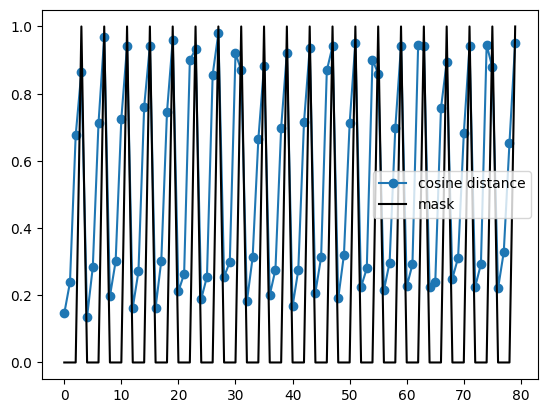

In [102]:
span = 80
plt.plot(dis_array[1:span+1], '-o', label='cosine distance')
plt.plot(mask[1:span+1], c='k', label = 'mask')
plt.legend()

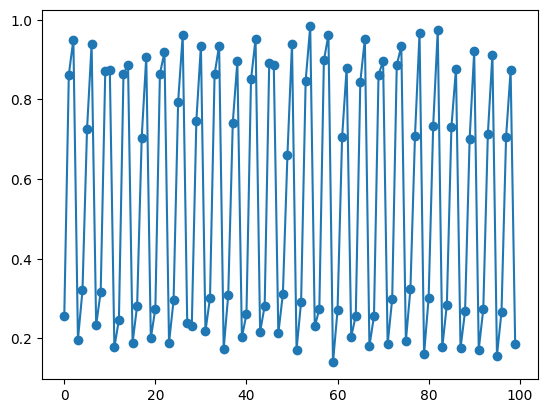

In [103]:
span = 100
plt.plot(dis_array[-span:], '-o')
# plt.plot(np.arange(span), [threshold]*span, '--', c='k')

In [104]:
mask[-100:]

array([0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1])

In [105]:
data_set = Dataset_converter_compressor(data_compressor, mask)
compressor_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
compression = []

compressor_model = compressor(input_size, hidden_compressor_size)
optimizer = torch.optim.SGD(compressor_model.parameters(), lr=4e-4, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct = np.zeros(1000, dtype=float)
for X, y in compressor_loader:
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden = compressor_model(X)
    else:
        predicted_y, hidden = compressor_model(X, hc=mem)
        
    loss = criterion(predicted_y, y)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        mem = hidden.clone()

        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=1)

        if estimated_y[0]:
            compression.append((true_y[0],estimated_y[0],tokens[X.argmax(axis=1)]))
            
        total += 1
        if true_y == estimated_y:
            correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')



Iter : 1001, loss: 0.1944, accuracy: 0.7240
Iter : 2001, loss: 0.0096, accuracy: 0.8240
Iter : 3001, loss: 0.0749, accuracy: 0.8590
Iter : 4001, loss: 0.0057, accuracy: 0.9180
Iter : 5001, loss: 0.0037, accuracy: 0.9460
Iter : 6001, loss: 0.0031, accuracy: 0.9690
Iter : 7001, loss: 0.0002, accuracy: 0.9680
Iter : 8001, loss: 0.0000, accuracy: 0.9770
Iter : 9001, loss: 0.0009, accuracy: 0.9810
Iter : 10001, loss: 0.0000, accuracy: 0.9850
Iter : 11001, loss: 0.0008, accuracy: 0.9900
Iter : 12001, loss: 0.0000, accuracy: 0.9930
Iter : 13001, loss: 0.0000, accuracy: 0.9950
Iter : 14001, loss: 0.0000, accuracy: 0.9950
Iter : 15001, loss: 0.0000, accuracy: 0.9950
Iter : 16001, loss: 0.0001, accuracy: 0.9990
Iter : 17001, loss: 0.0000, accuracy: 0.9940
Iter : 18001, loss: 0.0000, accuracy: 0.9960
Iter : 19001, loss: 0.0001, accuracy: 0.9980


In [106]:
compressed_seq = ''
data = get_sequence(3000, n_community, n_members, train=False)
data_test = Dataset_converter_compressor(data, mask)
test_loader = DataLoader(data_test, batch_size=1, shuffle=False) 

total = 0
correct = np.zeros(1000, dtype=float)
for X, y in test_loader:      

    with torch.no_grad():
        if total == 0:
            predicted_y, hidden = compressor_model(X)
        else:
            predicted_y, hidden = compressor_model(X, hc=hidden)


        # if total<8:
        #     print(X)
        # print(y, predicted_y)
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=1)

        if estimated_y[0]:
            compressed_seq += tokens[X.argmax(axis=1)]
            
        total += 1

In [107]:
compressed_seq[-100:]

'CILOCILOLCILLJLFLJIIIOLCOFFOFOFILILIFLKCOLFLJOOCIFOOFOCCILFCBCCCIOCILOLOOOIFLKOOCCIOLLJCCFOOCCCFFFOF'

In [108]:
sleep_samples = 50000
compressed_seq = ''
data_sleep = get_sequence(sleep_samples, n_community, n_members)
data_set_sleep = Dataset_converter(data_sleep, working_memory, short_term_memory)

sleep_loader = DataLoader(data_set_sleep, batch_size=1, shuffle=False)

network1.rnn.requires_grad = False
network1.wake_fc.requires_grad = False

optimizer = torch.optim.SGD(network1.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
hidden_s = None
correct = np.zeros(1000,dtype=float)
for X, y in sleep_loader:

    with torch.no_grad():
        if total == 0:
            community = X.clone()
            prev_community = X.clone()
            predicted_y, hidden = compressor_model(X[0])
        else:
            predicted_y, hidden = compressor_model(X[0], hc=hidden)

        selection = predicted_y.argmax(axis=1)

        # if selection:
        #     sleep = True
        #     compressed_seq += data_sleep[total]
        #     X_ = y_.clone()
        #     y_ = X.clone()
        #     # print(X_,y_)
        # else:
        #     sleep = False

        if selection:        
            # print(data_sleep[total],'com')
            compressed_seq += data_sleep[total]
            community = prev_community.clone()
            prev_community = X.clone()
    ####################################################################
    optimizer.zero_grad()
    # print(data_sleep[total])
    if total == 0:
        predicted_y, hidden_w, hidden_s = network1(X, community, sleep=True)
    else:
        predicted_y, hidden_w, hidden_s = network1(X, community, hw=mem, hs=mem_, sleep=True)
        
    loss = criterion(predicted_y[0], y)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        mem=hidden_w.clone()
        mem_=hidden_s.clone()
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=2)

        total += 1
        if true_y == estimated_y:
                correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')

Iter : 1001, loss: 2.3338, accuracy: 0.6970
Iter : 2001, loss: 2.1937, accuracy: 0.6970
Iter : 3001, loss: 2.1764, accuracy: 0.7050
Iter : 4001, loss: 2.1583, accuracy: 0.7050
Iter : 5001, loss: 2.2779, accuracy: 0.7070
Iter : 6001, loss: 2.3290, accuracy: 0.7050
Iter : 7001, loss: 2.3946, accuracy: 0.7180
Iter : 8001, loss: 2.5030, accuracy: 0.7190
Iter : 9001, loss: 2.3651, accuracy: 0.7080
Iter : 10001, loss: 2.2155, accuracy: 0.7050
Iter : 11001, loss: 2.4035, accuracy: 0.7140
Iter : 12001, loss: 2.3664, accuracy: 0.7140
Iter : 13001, loss: 2.3415, accuracy: 0.7060
Iter : 14001, loss: 2.3979, accuracy: 0.7150
Iter : 15001, loss: 2.3598, accuracy: 0.7230
Iter : 16001, loss: 2.5594, accuracy: 0.7130
Iter : 17001, loss: 2.3282, accuracy: 0.7180
Iter : 18001, loss: 2.3128, accuracy: 0.7160
Iter : 19001, loss: 2.0414, accuracy: 0.7300
Iter : 20001, loss: 2.2023, accuracy: 0.7060
Iter : 21001, loss: 2.1829, accuracy: 0.7130
Iter : 22001, loss: 2.4300, accuracy: 0.7160
Iter : 23001, loss:

In [88]:
compressor_sample = 20000
communities = []
data_compressor = get_sequence(compressor_sample, n_community, n_members, train=False)
data_set_compressor = Dataset_converter(data_compressor, working_memory, short_term_memory)
compressor_loader = DataLoader(data_set_compressor, batch_size=1, shuffle=False) 

ii = 0
dis = [0]
# community = ''

with torch.no_grad():
    for X, _ in compressor_loader:
        with torch.no_grad():
            if ii == 0:
                community = X.clone()
                prev_community = X.clone()
                predicted_y, hidden = compressor_model(X[0])
            else:
                predicted_y, hidden = compressor_model(X[0], hc=hidden)
    
            selection = predicted_y.argmax(axis=1)
    
            if selection:        
                community = prev_community.clone()
                communities.append((tokens[community.argmax()],ii))
                prev_community = X.clone()
            ####################################################################

            if ii == 0:
                predicted_y, hw, hs = network1(X, community, sleep=True)
                id_current = hw
            else:
                predicted_y, hw, hs = network1(X, community, hw=hw, hs=hs, sleep=True)
                id_current = hw

                if ii>=1:
                    dis.append(compute_geodesic(prev_id, id_current))
                        
                
            prev_id = id_current
            ii += 1

In [89]:
dis_array = np.array(dis)
# threshold = np.quantile(dis_array, .8)
# peaks = find_peaks(dis_array, .6)[0]
peaks = [-100] 
threshold = 0.2
prev_dis = 1

for ii, dis in enumerate(dis_array):
    if prev_dis - dis >= threshold and peaks[-1]!=ii-2:
        peaks.append(ii-1)
    
    prev_dis = dis 

peaks.pop(0)
mask = np.zeros(dis_array.shape, dtype=int)
mask[peaks] = 1
# mask = ((dis_array>threshold)*1)

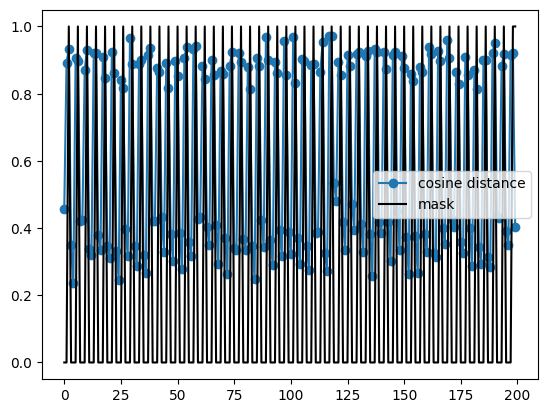

In [90]:
span = 200
plt.plot(dis_array[-span:], '-o', label='cosine distance')
plt.plot(mask[-span:], c='k', label = 'mask')
plt.legend()

In [22]:
for ii in range(span):
    print(data_compressor[compressor_sample-1-span+ii], compressor_sample-1-span+ii+4)

P 19803
L 19804
K 19805
J 19806
P 19807
O 19808
M 19809
N 19810
P 19811
I 19812
H 19813
G 19814
P 19815
F 19816
E 19817
D 19818
P 19819
I 19820
G 19821
H 19822
P 19823
L 19824
K 19825
J 19826
P 19827
L 19828
J 19829
K 19830
P 19831
O 19832
N 19833
M 19834
P 19835
C 19836
B 19837
A 19838
P 19839
C 19840
A 19841
B 19842
P 19843
L 19844
K 19845
J 19846
P 19847
I 19848
H 19849
G 19850
P 19851
F 19852
E 19853
D 19854
P 19855
C 19856
B 19857
A 19858
P 19859
C 19860
A 19861
B 19862
P 19863
I 19864
H 19865
G 19866
P 19867
L 19868
K 19869
J 19870
P 19871
O 19872
N 19873
M 19874
P 19875
I 19876
H 19877
G 19878
P 19879
L 19880
K 19881
J 19882
P 19883
F 19884
E 19885
D 19886
P 19887
L 19888
J 19889
K 19890
P 19891
O 19892
N 19893
M 19894
P 19895
L 19896
J 19897
K 19898
P 19899
L 19900
J 19901
K 19902
P 19903
I 19904
H 19905
G 19906
P 19907
O 19908
N 19909
M 19910
P 19911
O 19912
M 19913
N 19914
P 19915
C 19916
B 19917
A 19918
P 19919
C 19920
A 19921
B 19922
P 19923
F 19924
E 19925
D 19926
P 19927


In [736]:
communities[-span//2+1:]

[('P', 19404),
 ('V', 19408),
 ('F', 19412),
 ('E', 19416),
 ('W', 19420),
 ('B', 19424),
 ('F', 19428),
 ('S', 19432),
 ('Z', 19436),
 ('U', 19440),
 ('W', 19444),
 ('V', 19448),
 ('H', 19452),
 ('P', 19456),
 ('N', 19460),
 ('G', 19464),
 ('F', 19468),
 ('^', 19472),
 ('T', 19476),
 ('J', 19480),
 ('O', 19484),
 ('Q', 19488),
 ('U', 19492),
 ('J', 19496),
 ('W', 19500),
 ('[', 19504),
 ('M', 19508),
 ('F', 19512),
 (']', 19516),
 ('N', 19520),
 ('W', 19524),
 ('L', 19528),
 ('H', 19532),
 ('W', 19536),
 ('M', 19540),
 ('M', 19544),
 ('Z', 19548),
 ('C', 19552),
 ('X', 19556),
 ('X', 19560),
 ('Y', 19564),
 ('Q', 19568),
 ('C', 19572),
 ('C', 19576),
 (']', 19580),
 ('[', 19584),
 ('X', 19588),
 ('Z', 19592),
 ('G', 19596),
 ('M', 19600),
 ('S', 19604),
 ('C', 19608),
 ('V', 19612),
 ('[', 19616),
 ('P', 19620),
 ('M', 19624),
 ('J', 19628),
 (']', 19632),
 ('R', 19636),
 ('[', 19640),
 ('L', 19644),
 ('X', 19648),
 ('S', 19652),
 ('J', 19656),
 ('\\', 19660),
 ('E', 19664),
 ('R', 19

In [219]:
a = [ 2, 1,3]
b = [2,2,3]

In [220]:
a==b

False

In [221]:
a.sort()

In [222]:
a

[1, 2, 3]

In [23]:
data_compressor

'...'